In [3]:
import os
import yaml
import pandas as pd
from yaml import CSafeLoader as SafeLoader
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
import json
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [4]:

def safe_json_loads(val):
    if pd.isna(val) or val is None:
        return None
    try:
        if isinstance(val, dict):
            return val
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        return val

In [5]:

data_folder = 'data'
all_data = []
stream_points = []
mt45_steps = []
all_activities = set()

# 1. Scan files and extract metadata, activities, and stream points
for f_name in os.listdir(data_folder):
    if f_name.endswith(('.yaml', '.yml')):
        path = os.path.join(data_folder, f_name)
        try:
            with open(path, 'r', encoding='utf-8') as f:
                docs = list(yaml.load_all(f, Loader=SafeLoader))
                collect_following_mt45_events = False

                
                f_ts, f_trace, f_id = None, None, None
                for doc in docs:
                    
                    if not doc: continue
                    
                    # Metadata
                    if 'log' in doc and 'trace' in doc['log']:
                        t = doc['log']['trace']
                        f_trace = t.get('cpee:name') or t.get('concept:name')
                        f_id = t.get('concept:name')

                    
                    if 'event' in doc:

                        ev = doc['event']
                        act = ev.get('concept:name')
                        if act: all_activities.add(act)
                        if f_ts is None: f_ts = ev.get('time:timestamp')
                        
                        # 2. Extract Nested TimeSeries (stream:datastream)
                        if 'stream:datastream' in ev:
                            for item in ev['stream:datastream']:
                                if 'stream:point' in item:
                                    p = item['stream:point']
                                    axis = p.get('stream:id')
                                    if "Pos." in str(axis) or "RobJoint.Rax" in str(axis):
                                        stream_points.append({
                                            'file': f_name,
                                            's_ts': pd.to_datetime(p.get('stream:timestamp')),
                                            'axis':axis, # e.g., Pos.X, StateMachine
                                            'val': p.get('stream:value')
                                        })
                        
                        # Extract MT45 events with timestamp
                        if str(act).startswith("MT45") or collect_following_mt45_events:
                            if not collect_following_mt45_events:
                                collect_following_mt45_events = True
                            entry = {
                                'file': f_name,
                                's_ts': pd.to_datetime(ev.get('time:timestamp')),
                                "act":str(act),
                                "lifecycle": ev.get("cpee:lifecycle:transition"),
                                "data":None
                            }

                            if "raw" in ev:
                                data = ev.get('raw')
                                if isinstance(data, list):
                                    data = data[0].get('data')
                                entry["data"] = data
                            
                            mt45_steps.append(entry)
                        
                
                if f_ts:
                    all_data.append({'file': f_name, 'ts': pd.to_datetime(f_ts), 'trace': str(f_trace), 'id': str(f_id)})
        except: pass




In [6]:


df_files = pd.DataFrame(all_data).sort_values('ts').reset_index(drop=True)
df_files['is_start'] = df_files['trace'].str.contains('Turm Single', case=False, na=False)
df_files['bin_id'] = df_files['is_start'].cumsum()

labels = df_files[df_files['is_start']].set_index('bin_id')['id'].to_dict()
df_files['bin_label'] = df_files['bin_id'].map(labels).fillna('Preprocess')

result_dict = df_files.groupby('bin_label')['file'].apply(list).to_dict()

for label, files in result_dict.items():
    print(f"\nBIN: {label} ({len(files)} files)")
    print(files)



BIN: 5565 (25 files)
['14eb245e-9aba-446f-9624-2f110624dc65.xes.yaml', '16578c3c-f84b-4649-ac1a-24bf73f89f27.xes.yaml', 'f9b0528d-cd74-47a3-83d9-2eb2fc129dcb.xes.yaml', 'fdad9534-3d40-4767-9241-38b29857b2bc.xes.yaml', '85d7b38f-ba45-4157-9cce-4201403ab9b8.xes.yaml', 'f6dfced9-5cbf-4ddf-887c-f13373326b94.xes.yaml', '6c977a0c-947b-4c11-8bcb-d83a3ed22eb0.xes.yaml', 'f379675e-2f84-4b04-afd3-dc495334f643.xes.yaml', '3141b1b3-6557-461c-b288-58869e33595e.xes.yaml', '9851ce02-7cdd-49e2-8921-ad5ae4f7502c.xes.yaml', '5bf5853a-cd5b-4b76-ba9a-e40c2382d9be.xes.yaml', 'f316beb2-3ef3-4f7d-90d5-4a23eff5a831.xes.yaml', 'd0d21ef5-26df-4140-82fb-13b7cdc78de1.xes.yaml', 'd6e24a79-97f6-4bd6-824c-73acb08bac3e.xes.yaml', '678ee86f-c3df-45df-b11f-d1108eb2ebf2.xes.yaml', '91e67eb4-6558-4231-9e36-e5e092126f4f.xes.yaml', '853d4080-0d53-4aea-93fc-4569a9eb51d0.xes.yaml', '96f72277-e459-4a22-8678-b249763eff14.xes.yaml', '54e66d21-39b9-4405-b6c1-69374edd246a.xes.yaml', '144074e1-1414-4442-9002-9f1417b070ee.xes.yaml

In [7]:
print("\nUNIQUE ACTIVITIES (concept:name):")
for a in sorted(all_activities):
    if 'IRB' in str(a) or 'MT' in str(a) or 'Keyence' in str(a):
        print(f"- {a}")


UNIQUE ACTIVITIES (concept:name):
- IRB2600 Door to GS
- IRB2600 Door to Measure
- IRB2600 Door to Portal
- IRB2600 Extract
- IRB2600 GS to Door
- IRB2600 GS to Take
- IRB2600 Grip
- IRB2600 Measure to Door
- IRB2600 Portal to Door
- IRB2600 Take to GS
- IRB2600 Unload to Tray Down
- MT45 Check Operational Safety
- MT45 Start
- MT45 Take Out
- Measure with Keyence
- Set Program MT45
- Signal Keyence End
- Wait for MT45 Takeout


W logach systemu kada aktywność składa się z etapów:
- *activity/call*: ządanie zadanie
- *activity/receive*: odbieranie danych z maszyny podczas wykonywania zadania
- *activity/done*: zadanie zakończone

### IRB 2600

Nazwy sugerują, że robot porusza się między kilkoma kluczowymi punktami: 
- Door (drzwi maszyny)
- GS (Gaging Station – stacja pomiarowa)
- Portal (suwnica/przejście)
- Tray (taca/magazyn).

In [8]:
print("\nUNIQUE IRB2600 ACTIVITIES (concept:name):")
for a in sorted(all_activities):
    if 'IRB' in str(a):
        print(f"- {a}")


UNIQUE IRB2600 ACTIVITIES (concept:name):
- IRB2600 Door to GS
- IRB2600 Door to Measure
- IRB2600 Door to Portal
- IRB2600 Extract
- IRB2600 GS to Door
- IRB2600 GS to Take
- IRB2600 Grip
- IRB2600 Measure to Door
- IRB2600 Portal to Door
- IRB2600 Take to GS
- IRB2600 Unload to Tray Down



**Logistyka wewnętrzna (Portal & Door):**

- IRB2600 Door to Portal / Portal to Door: Robot przejeżdża przez "bramę" (punkt bezpieczeństwa) prowadzącą do wnętrza maszyny CNC.

**Obsługa detalu w maszynie:**
- IRB2600 Extract: Fizyczne wyciągnięcie gotowego elementu z uchwytu maszyny.

- IRB2600 Grip: Zaciśnięcie chwytaka na detalu.

**Kontrola Jakości (Measure & GS):**

- IRB2600 Door to Measure / Measure to Door: Przeniesienie detalu do stacji pomiarowej (laserowej lub stykowej).

- IRB2600 Take to GS / GS to Take: Operacje na stacji pomiarowej Gaging Station (GS).

- IRB2600 GS to Door / IRB2600 Door to GS: Powrót ze stacji pomiarowej pod drzwi maszyny (np. jeśli detal wymaga poprawki).

**Zakończenie**:

- IRB2600 Unload to Tray Down: Odłożenie detalu na tacę (magazyn gotowych wyrobów).

In [9]:

df_stream = pd.DataFrame(stream_points)

# Merge stream points with bin labels using 'file' as key
if not df_stream.empty:
    df_stream = df_stream.merge(df_files[['file', 'bin_label']], on='file', how='left')
    # Pivot to have X, Y, Z as separate columns for easier plotting
    df_plot = df_stream.pivot_table(index=['bin_label', 's_ts'], columns='axis', values='val').reset_index()
    print("\nTimeSeries Data Sample:")
    print(df_plot.head())
else:
    print("\nNo stream points found.")




TimeSeries Data Sample:
axis bin_label                                s_ts      Pos.X       Pos.Y  \
0         5565 2023-04-28 17:03:27.316377400+02:00        NaN         NaN   
1         5565 2023-04-28 17:03:27.721978100+02:00        NaN         NaN   
2         5565 2023-04-28 17:03:27.768778200+02:00 -13.580664  746.064941   
3         5565 2023-04-28 17:03:29.890381900+02:00        NaN         NaN   
4         5565    2023-04-28 17:03:29.937182+02:00  37.198242  739.791400   

axis       Pos.Z  RobJoint.Rax_1  RobJoint.Rax_2  RobJoint.Rax_3  \
0            NaN             NaN      -17.849617             NaN   
1            NaN       90.716415             NaN       17.031948   
2     1014.45959             NaN             NaN             NaN   
3            NaN       87.549760      -18.431732       19.608332   
4      977.30060             NaN             NaN             NaN   

axis  RobJoint.Rax_4  RobJoint.Rax_5  RobJoint.Rax_6  
0                NaN             NaN            

In [10]:
unique_bins = df_stream['bin_label'].unique()
print(sorted((unique_bins).astype(int)))

[np.int64(5565), np.int64(5590), np.int64(5619), np.int64(5646), np.int64(5672), np.int64(5697), np.int64(5721), np.int64(5746), np.int64(5771)]


### Ruch

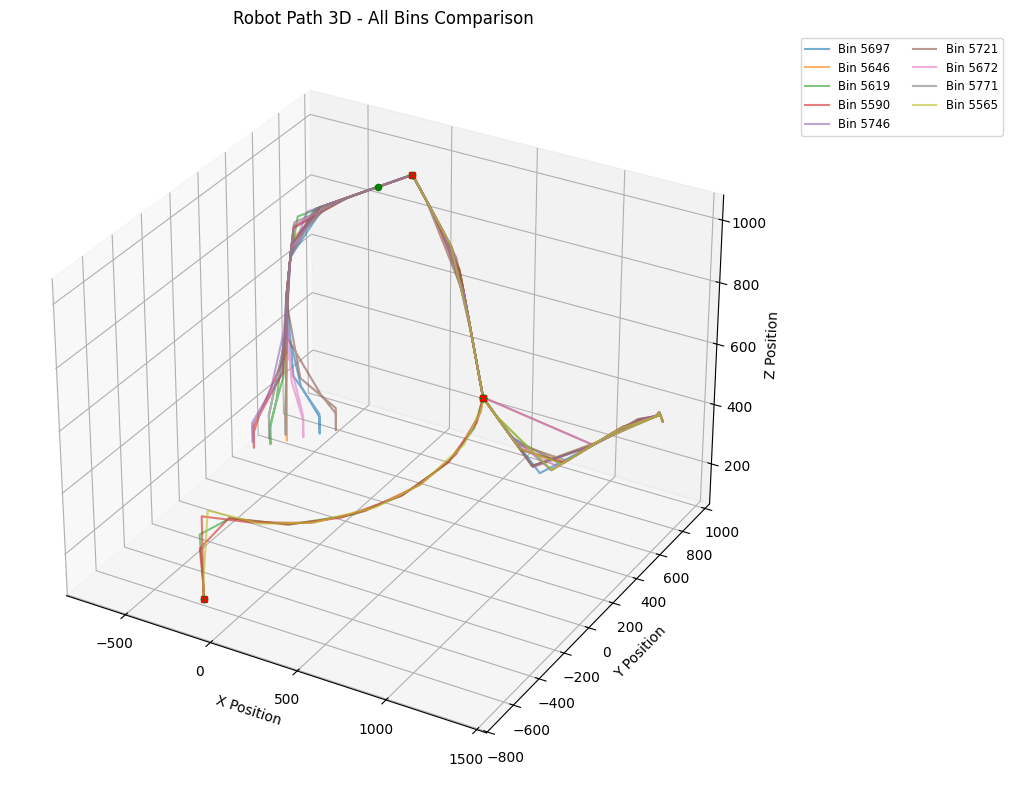


Wygenerowane cechy sensoryczne do Milestone 2:
            path_length  max_velocity      x_range      y_range  z_min_reach
bin_label                                                                   
5697        5736.278171    253.295180  2032.201870   464.440800   149.302567
5646        7573.428395    251.776601  2029.422793   459.408253   149.280914
5619        8787.938603    252.214206  2032.424010  1601.010800   128.119843
5590       10831.823312    257.424199  2063.864800  1596.849569   128.122833
5746        6819.617180    252.283664  2099.266964   548.830900   149.963058


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paths_list = []
feature_list = []

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
axes_to_plot = ['Pos.X', 'Pos.Y', 'Pos.Z']

for target_bin in unique_bins:
    if target_bin == 'Preprocess': continue
    
    mask = (df_stream['bin_label'] == target_bin) & (df_stream['axis'].isin(axes_to_plot))
    df_bin = df_stream[mask].copy()
    
    if df_bin.empty: continue
        
    df_pivot = df_bin.pivot_table(index='s_ts', columns='axis', values='val', aggfunc='mean').dropna()
    df_pivot = df_pivot.sort_index()
    df_pivot.columns = [c.replace('Pos.', '') for c in df_pivot.columns]
    
    diffs = df_pivot[['X', 'Y', 'Z']].diff().dropna()
    dist = np.sqrt((diffs**2).sum(axis=1)).sum()
    
    dt = df_pivot.index.to_series().diff().dt.total_seconds().dropna()
    vel = np.sqrt((diffs**2).sum(axis=1)) / dt.replace(0, np.nan)
    max_vel = vel.dropna().max() if not vel.dropna().empty else 0
    
    x_range = df_pivot['X'].max() - df_pivot['X'].min()
    y_range = df_pivot['Y'].max() - df_pivot['Y'].min()
    z_min = df_pivot['Z'].min()

    feature_list.append({
        'bin_label': target_bin,
        'path_length': dist,
        'max_velocity': max_vel,
        'x_range': x_range,
        'y_range': y_range,
        'z_min_reach': z_min
    })

    temp_df = df_pivot.reset_index()
    temp_df['bin_label'] = target_bin
    paths_list.append(temp_df[['bin_label', 's_ts', 'X', 'Y', 'Z']])
    
    ax.plot(df_pivot['X'], df_pivot['Y'], df_pivot['Z'], label=f'Bin {target_bin}', alpha=0.6)
    ax.scatter(df_pivot['X'].iloc[0], df_pivot['Y'].iloc[0], df_pivot['Z'].iloc[0], s=20, color='green') # Start
    ax.scatter(df_pivot['X'].iloc[-1], df_pivot['Y'].iloc[-1], df_pivot['Z'].iloc[-1], marker='x', s=20, color='red') # End

df_paths = pd.concat(paths_list, ignore_index=True)
df_features_stream = pd.DataFrame(feature_list).set_index('bin_label')

# Wykończenie wykresu
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('Robot Path 3D - All Bins Comparison')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

# Sprawdź wynik cech
print("\nWygenerowane cechy sensoryczne do Milestone 2:")
print(df_features_stream.head())

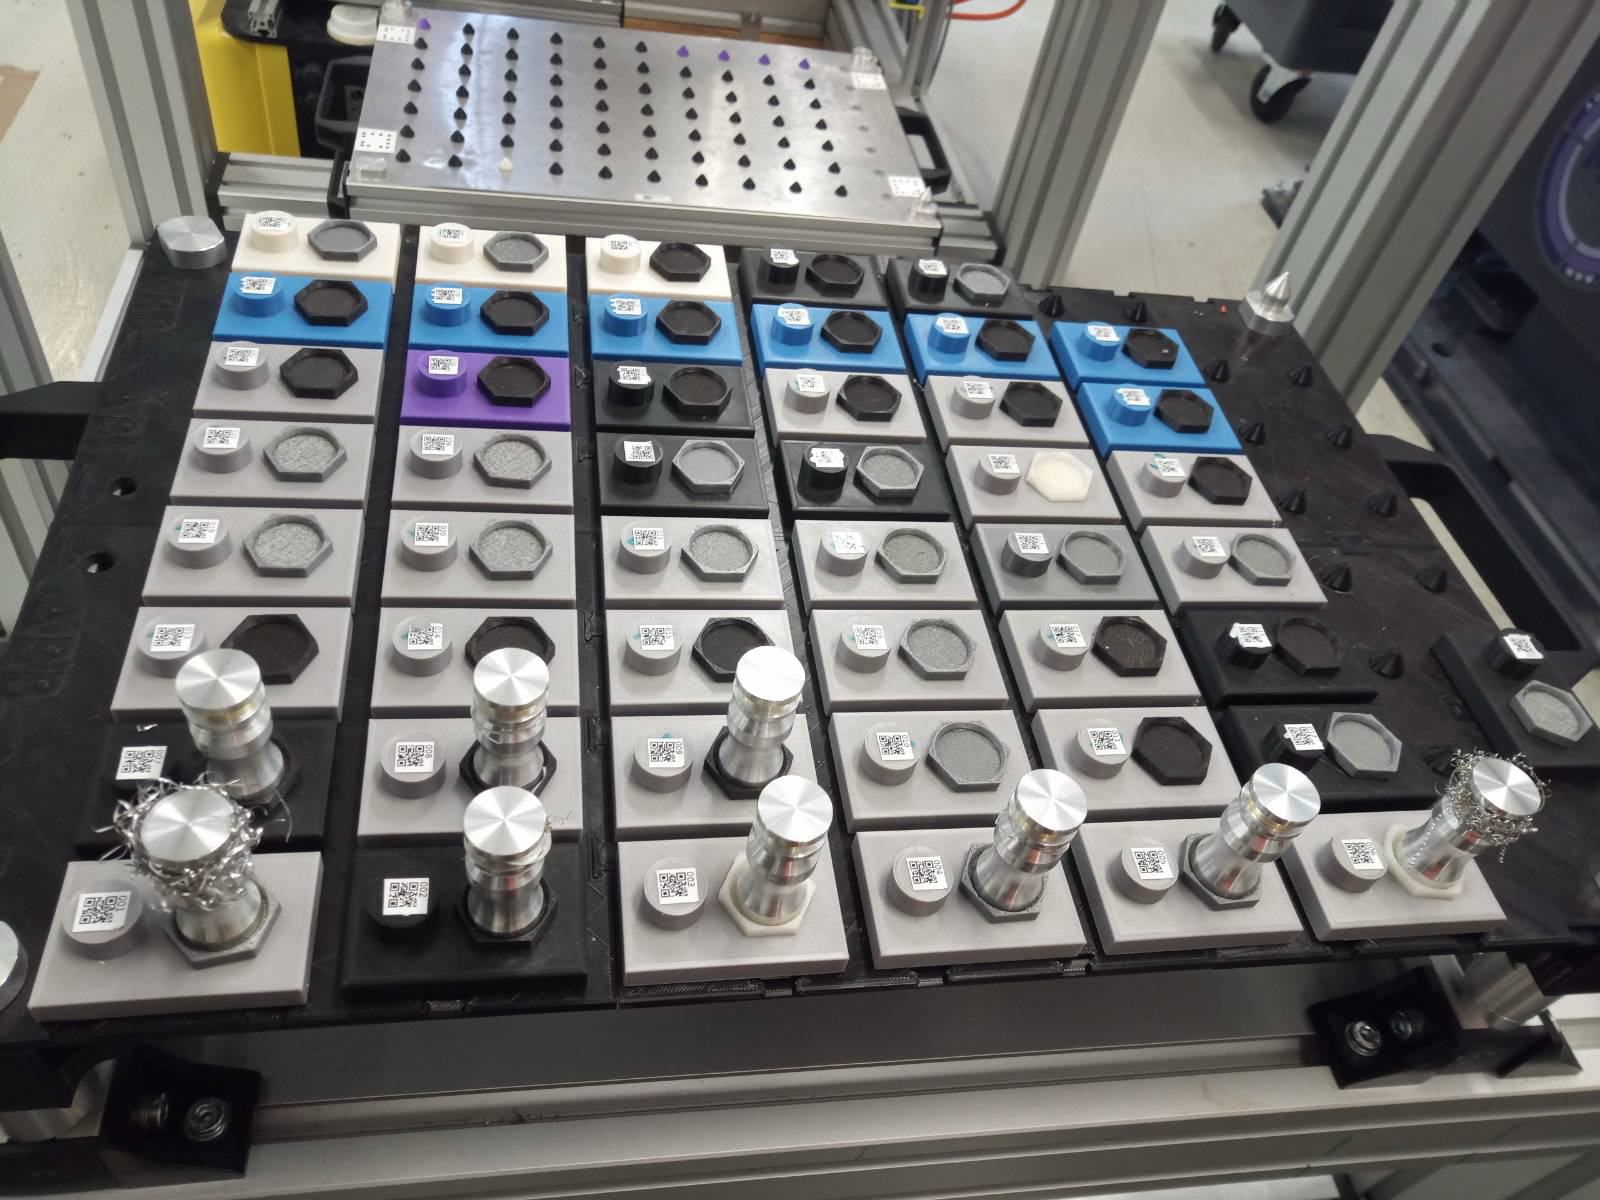

### Rotacja

- Rax_1 (Base): Obrót całego robota wokół własnej osi (lewo/prawo).

- Rax_2 (Lower Arm): Ruch ramienia do przodu i do tyłu.

- Rax_3 (Upper Arm): Ruch "łokcia" (góra/dół).

- Rax_4 (Wrist Rotation): Obrót przedramienia (osiowy).

- Rax_5 (Wrist Bend): Ruch nadgarstka (pochylenie góra/dół – bardzo ważne przy precyzyjnym podjeżdżaniu).

- Rax_6 (Tool Flange): Obrót samego chwytaka.

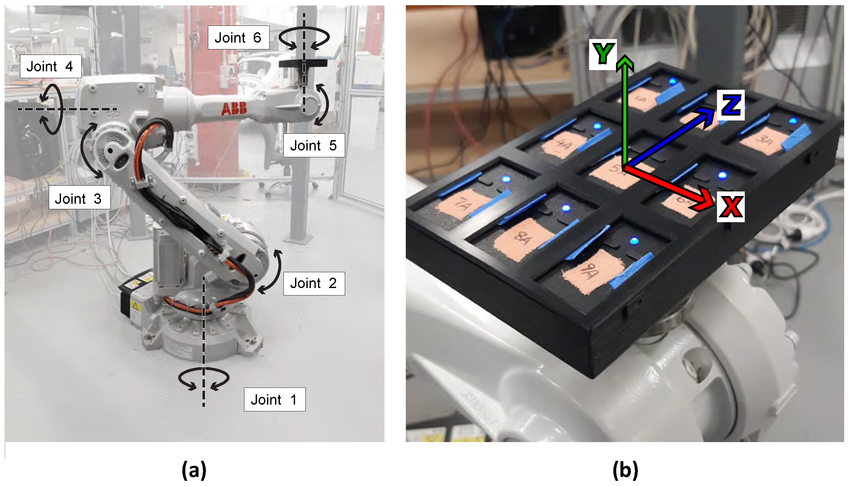

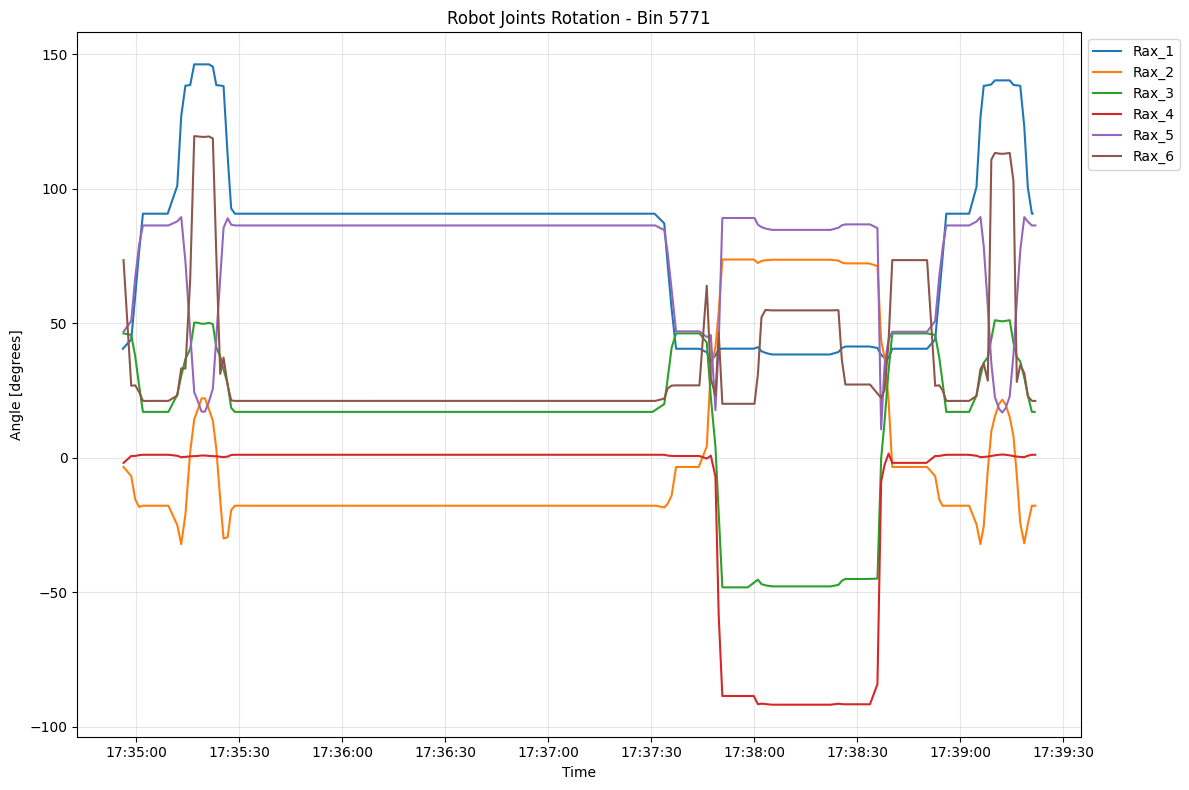

Sorted joints data for Bin 5771:
                               s_ts           axis       val
   2023-04-28 17:34:56.183295+02:00 RobJoint.Rax_1 40.505333
2023-04-28 17:34:56.370495300+02:00 RobJoint.Rax_4 -1.919976
2023-04-28 17:34:56.370495300+02:00 RobJoint.Rax_5 46.829147
2023-04-28 17:34:56.370495300+02:00 RobJoint.Rax_2 -3.443894
2023-04-28 17:34:56.370495300+02:00 RobJoint.Rax_3 46.212074
2023-04-28 17:34:56.370495300+02:00 RobJoint.Rax_6 73.459045
2023-04-28 17:34:58.616899300+02:00 RobJoint.Rax_2 -6.865413
2023-04-28 17:34:58.616899300+02:00 RobJoint.Rax_6 26.736044
2023-04-28 17:34:58.616899300+02:00 RobJoint.Rax_1 43.972897
2023-04-28 17:34:58.616899300+02:00 RobJoint.Rax_4  0.642471


In [12]:

joint_axes = [f'RobJoint.Rax_{i}' for i in range(1, 7)]
# example piece
target_bin = '5771'

df_joints = df_stream[(df_stream['axis'].isin(joint_axes)) & 
                      (df_stream['bin_label'] == target_bin)].copy()
df_joints = df_joints.sort_values('s_ts')

plt.figure(figsize=(12, 8))

for axis_name in sorted(joint_axes):
    data = df_joints[df_joints['axis'] == axis_name]
    plt.plot(data['s_ts'], data['val'], label=axis_name.split('.')[-1])

plt.title(f'Robot Joints Rotation - Bin {target_bin}')
plt.xlabel('Time')
plt.ylabel('Angle [degrees]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sorted joints data for Bin {target_bin}:")
print(df_joints[['s_ts', 'axis', 'val']].head(10).to_string(index=False))

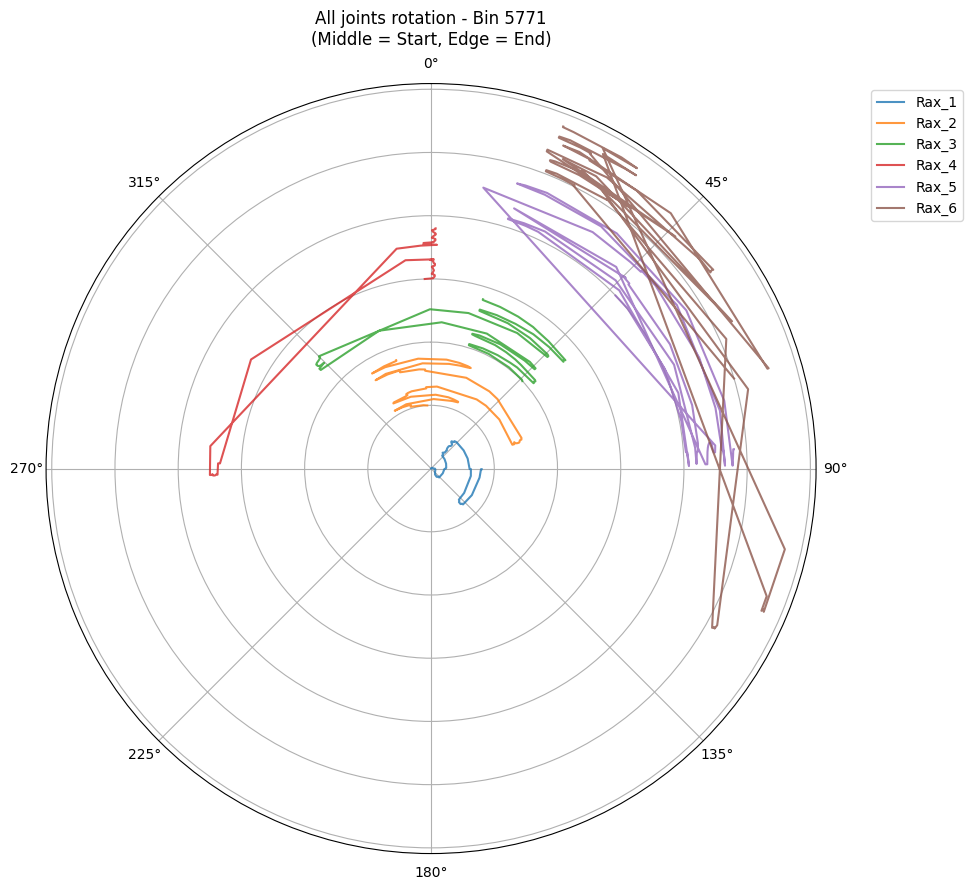

In [13]:
joint_axes = [f'RobJoint.Rax_{i}' for i in range(1, 7)]
df_b = df_stream[(df_stream['bin_label'] == target_bin) & (df_stream['axis'].isin(joint_axes))].copy()
df_b = df_b.sort_values('s_ts')

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

for i, axis_name in enumerate(sorted(joint_axes)):
    data = df_b[df_b['axis'] == axis_name].copy()
    if data.empty: continue
    
    theta = np.radians(data['val'])
    
    r = np.linspace(i, i + 0.8, len(data)) 
    
    ax.plot(theta, r, label=f'Rax_{i+1}', alpha=0.8)

ax.set_theta_zero_location('N') 
ax.set_theta_direction(-1)  
ax.set_yticklabels([])
plt.title(f"All joints rotation - Bin {target_bin}\n(Middle = Start, Edge = End)", va='bottom')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

plt.show()

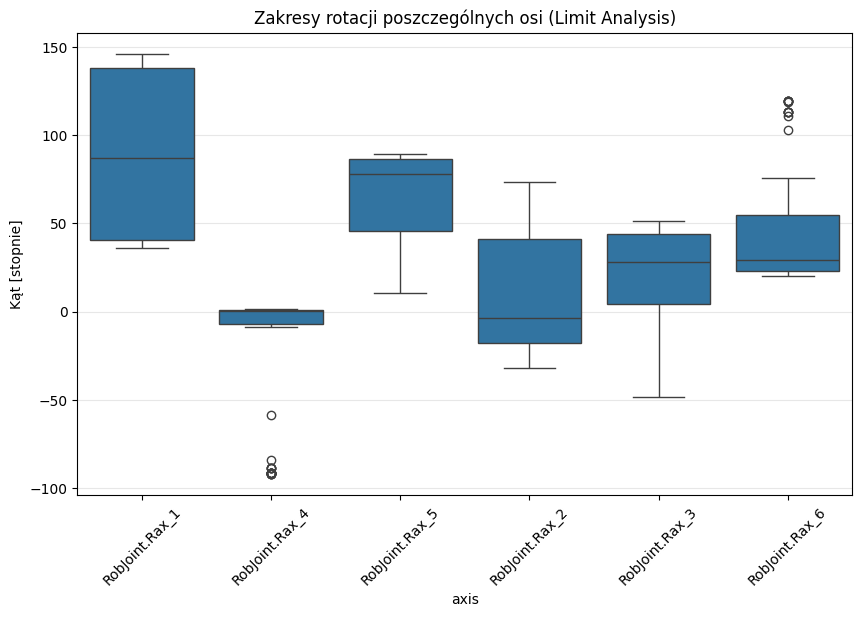

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='axis', y='val', data=df_joints)
plt.xticks(rotation=45)
plt.ylabel("Kąt [stopnie]")
plt.title("Zakresy rotacji poszczególnych osi (Limit Analysis)")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Tokarka MT45

In [15]:
target_bin = '5771'


print("\nUNIQUE MT45 ACTIVITIES (concept:name):")
for a in sorted(all_activities):
    if 'MT45' in str(a):
        print(f"- {a}")


UNIQUE MT45 ACTIVITIES (concept:name):
- MT45 Check Operational Safety
- MT45 Start
- MT45 Take Out
- Set Program MT45
- Wait for MT45 Takeout


In [16]:
df_mt45 = pd.DataFrame(mt45_steps)
if not df_mt45.empty:
    df_mt45 = df_mt45.merge(df_files[['file', 'bin_label']], on='file', how='left')
    print(df_mt45.head())

    df_mt45 = df_mt45.sort_values(['bin_label', 's_ts'])

    print("\n=== MT45 ACTIVITIES CATEGORIZED BY BIN ===")
    for b_label, group in df_mt45.groupby('bin_label'):
        print(f"\nBIN: {b_label}")
        print(group[['s_ts', 'act', 'lifecycle']].to_string(index=False))
else:
    print("\nNo MT45 data found.")


# Aplikujemy funkcję do kolumny
if not df_mt45.empty:
    df_mt45['data'] = df_mt45['data'].apply(safe_json_loads)

                                            file  \
0  3949633a-1fef-41f3-8552-8f4dad855efa.xes.yaml   
1  3949633a-1fef-41f3-8552-8f4dad855efa.xes.yaml   
2  3949633a-1fef-41f3-8552-8f4dad855efa.xes.yaml   
3  3949633a-1fef-41f3-8552-8f4dad855efa.xes.yaml   
4  3949633a-1fef-41f3-8552-8f4dad855efa.xes.yaml   

                              s_ts         act           lifecycle  \
0 2023-04-28 17:26:10.677000+02:00  MT45 Start    activity/calling   
1 2023-04-28 17:26:11.072000+02:00  MT45 Start  task/instantiation   
2 2023-04-28 17:26:11.072000+02:00  MT45 Start  activity/receiving   
3 2023-04-28 17:26:14.750000+02:00  MT45 Start  activity/receiving   
4 2023-04-28 17:26:33.883000+02:00  MT45 Start       activity/done   

                                                data bin_label  
0                                               None      5721  
1  {'CPEE-INSTANCE': '5726', 'CPEE-INSTANCE-URL':...      5721  
2  {"CPEE-INSTANCE":"5726","CPEE-INSTANCE-URL":"h...      5721  
3  {"C

In [17]:
def extract_cycle_tasks(df_mt45, target_bin):
    df_bin = df_mt45[df_mt45['bin_label'] == target_bin].sort_values('s_ts').copy()
    
    if df_bin.empty:
        return pd.DataFrame()

    refined_tasks = []
    ordered_acts = df_bin['act'].unique()
    
    for i, act_name in enumerate(ordered_acts):
        if i == 0:
            t_start = df_bin[df_bin['act'] == act_name]['s_ts'].min()
        else:
            prev_act = ordered_acts[i-1]
            done_event = df_bin[(df_bin['act'] == prev_act) & 
                                (df_bin['lifecycle'] == 'activity/done')]
            if not done_event.empty:
                t_start = done_event['s_ts'].iloc[0]
            else:
                t_start = df_bin[df_bin['act'] == act_name]['s_ts'].min()

        t_end = df_bin[df_bin['act'] == act_name]['s_ts'].max()
        duration = (t_end - t_start).total_seconds()
        
        if duration >= 0:
            refined_tasks.append({
                'Bin': target_bin,
                'Task': act_name,
                'Start': t_start,
                'End': t_end,
                'Duration': duration
            })

    return pd.DataFrame(refined_tasks)

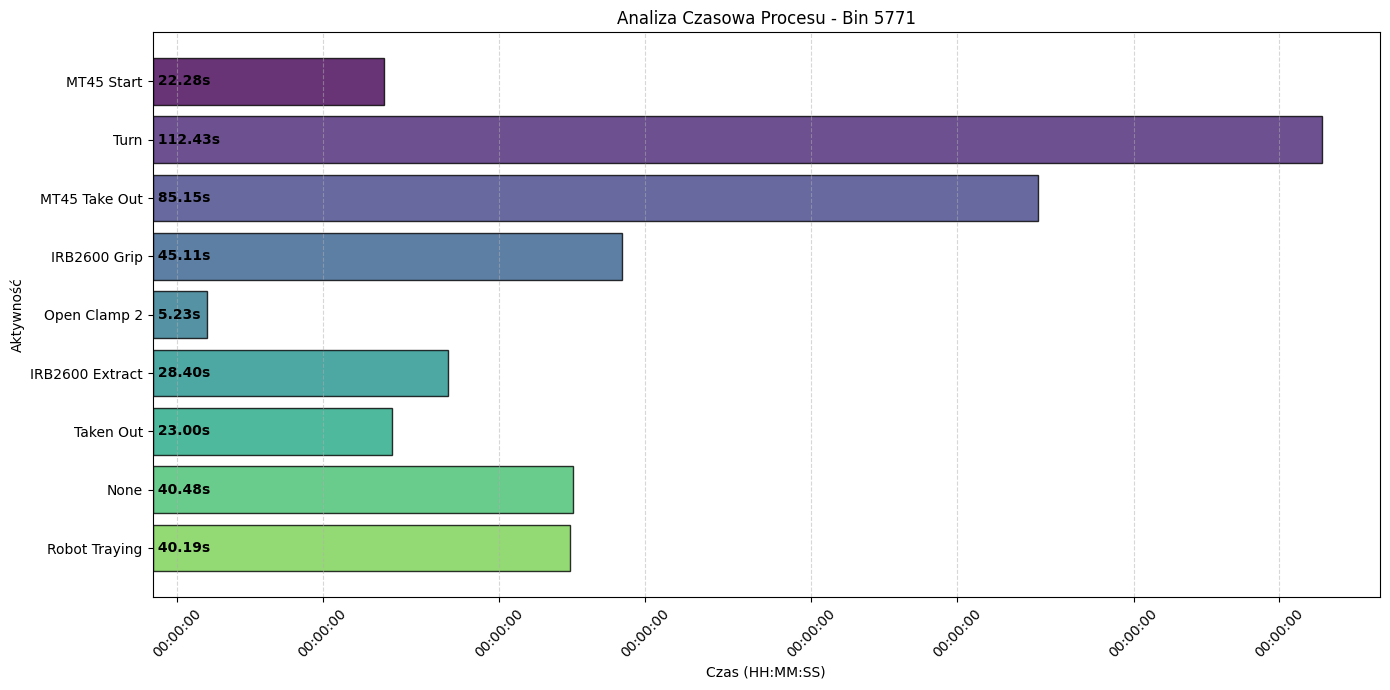

In [18]:
df_tasks = extract_cycle_tasks(df_mt45, target_bin)

if not df_tasks.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(df_tasks)))

    for i, row in enumerate(df_tasks.itertuples()):
        ax.barh(row.Task, row.Duration, left=row.Start, color=colors[i], edgecolor='black', alpha=0.8)
        ax.text(row.End, i, f' {row.Duration:.2f}s', va='center', fontsize=10, fontweight='bold')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.xticks(rotation=45)
    ax.set_xlabel('Czas (HH:MM:SS)')
    ax.set_ylabel('Aktywność')
    ax.set_title(f'Analiza Czasowa Procesu - Bin {target_bin}')

    ax.invert_yaxis() 
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

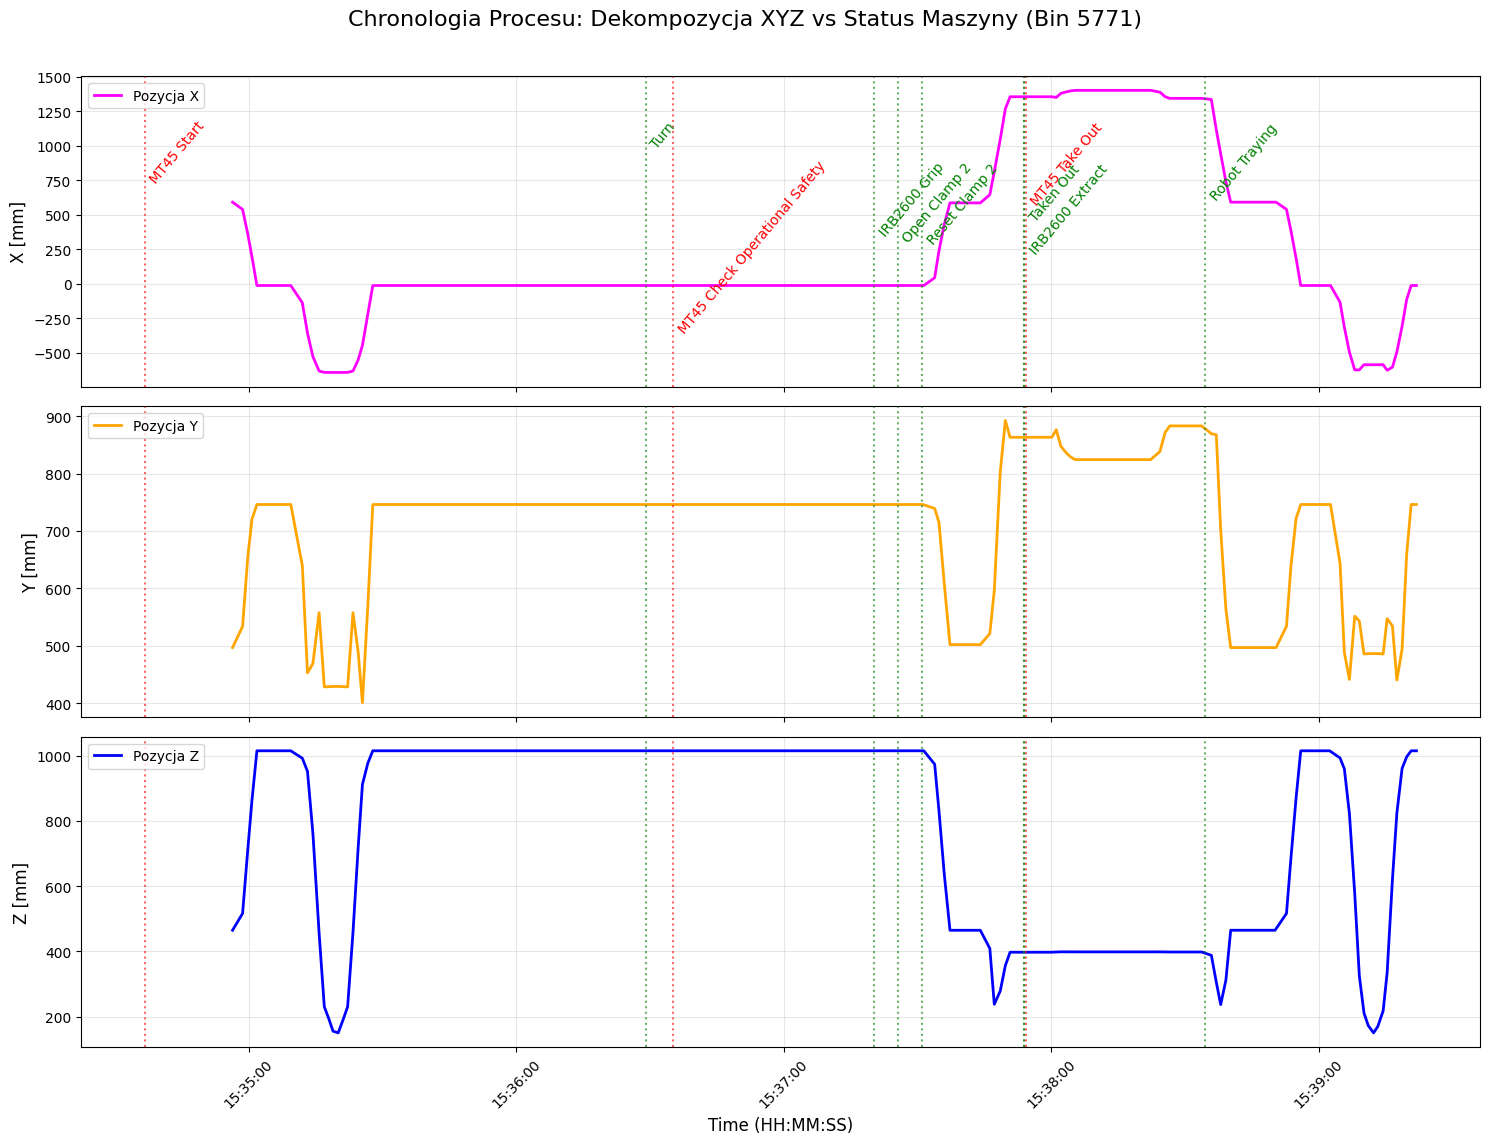

In [19]:
axes_to_plot = ['Pos.X', 'Pos.Y', 'Pos.Z']
colors = {'Pos.X': 'magenta', 'Pos.Y': 'orange', 'Pos.Z': 'blue'}

df_bin_stream = df_stream[df_stream['bin_label'] == target_bin].copy()
df_bin_stream['val'] = pd.to_numeric(df_bin_stream['val'], errors='coerce')
df_events = df_mt45[df_mt45['bin_label'] == target_bin].sort_values('s_ts')

fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i, axis_name in enumerate(axes_to_plot):
    ax = axs[i]
    df_axis = df_bin_stream[df_bin_stream['axis'] == axis_name].sort_values('s_ts')
    
    ax.plot(df_axis['s_ts'], df_axis['val'], color=colors[axis_name], label=f'Pozycja {axis_name[-1]}', linewidth=2)
    ax.set_ylabel(f'{axis_name[-1]} [mm]', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    for j, event in df_events[df_events['lifecycle'] == 'activity/done'].iterrows():
        color = 'red' if 'MT45' in event['act'] else 'green'
        ax.axvline(x=event['s_ts'], color=color, linestyle=':', alpha=0.6)
        
        if i == 0:
            y_lim = ax.get_ylim()
            ax.text(event['s_ts'], y_lim[1] * 0.9 - j, f" {event['act']}", 
                    rotation=50, verticalalignment='top', fontsize=10, color=color,)

axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
axs[2].set_xlabel('Time (HH:MM:SS)', fontsize=12)

fig.suptitle(f'Chronologia Procesu: Dekompozycja XYZ vs Status Maszyny (Bin {target_bin})', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

In [20]:

all_cycles_list = []
unique_bins = [b for b in df_mt45['bin_label'].unique() if b != 'Preprocess']

for bin_id in unique_bins:
    df_tasks = extract_cycle_tasks(df_mt45, bin_id)
    if not df_tasks.empty:
        all_cycles_list.append(df_tasks)

df_all_tasks = pd.concat(all_cycles_list, ignore_index=True)

name_map = {
    'Robot Measuring And Traying': 'Robot Traying (Total)',
    'Robot Traying': 'Robot Traying (Total)'
}
df_all_tasks['Task_Normalized'] = df_all_tasks['Task'].replace(name_map)
df_all_tasks = df_all_tasks[df_all_tasks['Task_Normalized'] != 'None']

df_all_tasks.head()

,Bin,Task,Start,End,Duration,Task_Normalized
0,5565,MT45 Start,2023-04-28 16:59:53.062000+02:00,2023-04-28 17:00:13.842000+02:00,20.780,MT45 Start
1,5565,Turn,2023-04-28 17:00:13.842000+02:00,2023-04-28 17:02:25.637000+02:00,131.795,Turn
2,5565,MT45 Take Out,2023-04-28 17:02:25.637000+02:00,2023-04-28 17:03:51.806000+02:00,86.169,MT45 Take Out
3,5565,IRB2600 Grip,2023-04-28 17:02:31.641000+02:00,2023-04-28 17:03:16.126000+02:00,44.485,IRB2600 Grip
4,5565,Open Clamp 2,2023-04-28 17:03:16.126000+02:00,2023-04-28 17:03:21.144000+02:00,5.018,Open Clamp 2


In [21]:
stats = df_all_tasks.groupby('Task_Normalized')['Duration'].agg(['mean', 'std', 'count']).reset_index()
stats = stats.sort_values('mean', ascending=False)

print("=== STATYSTYKI CZASOWE PROCESU (USZEREGOWANE WG ŚREDNIEJ) ===")
print(stats.to_string(index=False))

=== STATYSTYKI CZASOWE PROCESU (USZEREGOWANE WG ŚREDNIEJ) ===
              Task_Normalized       mean       std  count
                         Turn 120.598889  8.124035      9
                MT45 Take Out  95.453222 18.230351      9
         Measure with Keyence  86.862500  5.012680      2
                 IRB2600 Grip  45.123556  0.686664      9
        Robot Traying (Total)  43.712857  1.610670      7
              IRB2600 Extract  29.331111  1.098191      9
                    Taken Out  23.525556  0.498138      9
                   MT45 Start  22.516222  0.800749      9
                 Open Clamp 2   5.378444  0.288253      9
MT45 Check Operational Safety   3.085000       NaN      1
  Robot Measuring and Traying   0.249000  0.025456      2
           Signal Keyence End   0.047000  0.012728      2


/var/folders/h9/wcf716hj6t96gm_lz5tzq4jr0000gn/T/ipykernel_46251/2429485245.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Duration', y='Task_Normalized', palette=cmap, ax=ax)
/var/folders/h9/wcf716hj6t96gm_lz5tzq4jr0000gn/T/ipykernel_46251/2429485245.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Duration', y='Task_Normalized', palette=cmap, ax=ax)
/var/folders/h9/wcf716hj6t96gm_lz5tzq4jr0000gn/T/ipykernel_46251/2429485245.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Durati

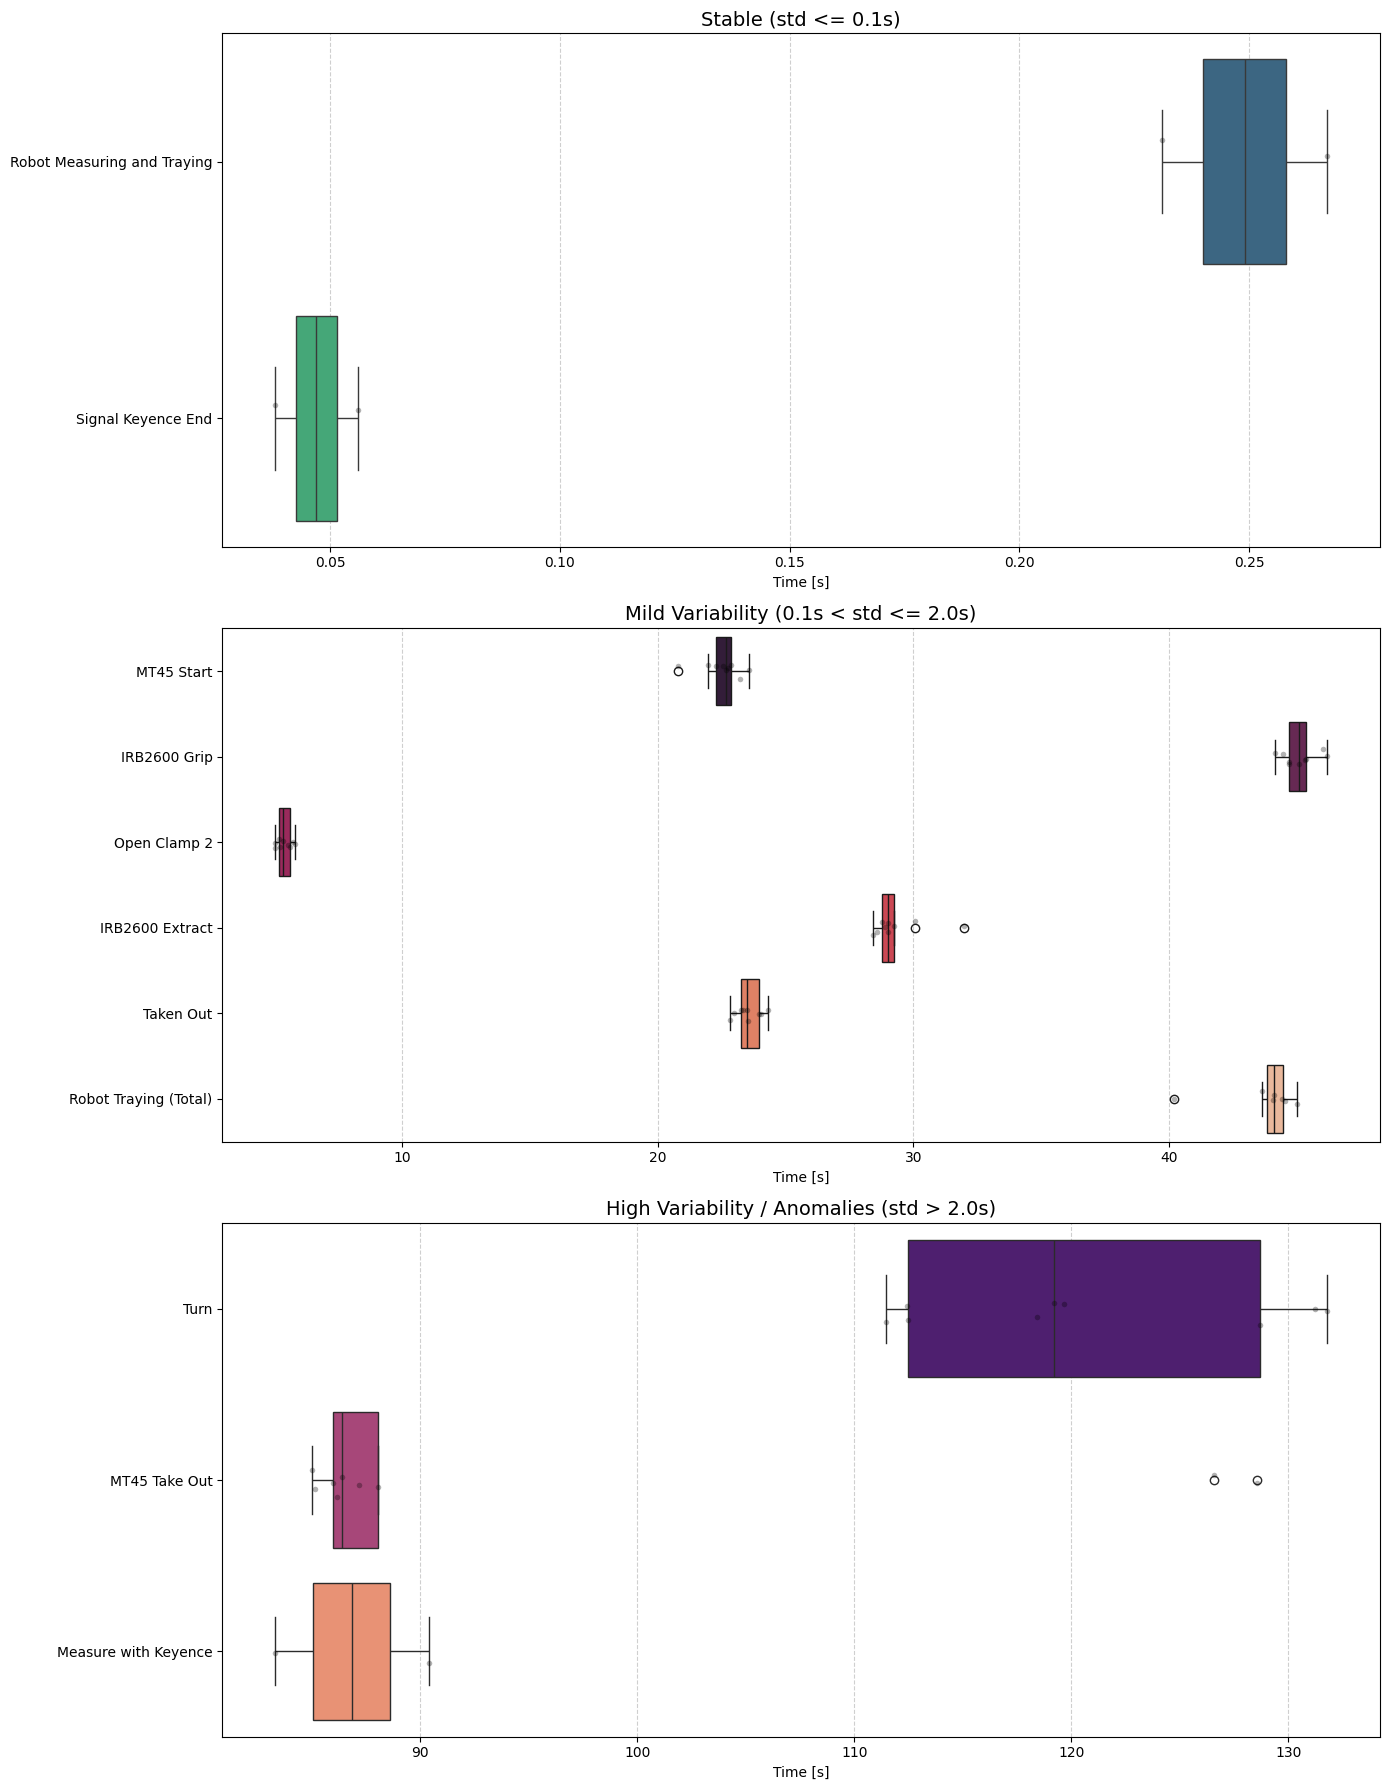

              Task_Normalized       mean       std        var
                MT45 Take Out  95.453222 18.230351 332.345710
                         Turn 120.598889  8.124035  65.999948
         Measure with Keyence  86.862500  5.012680  25.126960
        Robot Traying (Total)  43.712857  1.610670   2.594257
              IRB2600 Extract  29.331111  1.098191   1.206024
                   MT45 Start  22.516222  0.800749   0.641199
                 IRB2600 Grip  45.123556  0.686664   0.471507
                    Taken Out  23.525556  0.498138   0.248141
                 Open Clamp 2   5.378444  0.288253   0.083090
  Robot Measuring and Traying   0.249000  0.025456   0.000648
           Signal Keyence End   0.047000  0.012728   0.000162
MT45 Check Operational Safety   3.085000       NaN        NaN
              Task_Normalized       mean       std        var
                MT45 Take Out  95.453222 18.230351 332.345710
                         Turn 120.598889  8.124035  65.999948
        

In [22]:
stats = df_all_tasks.groupby('Task_Normalized')['Duration'].agg(['mean', 'std', 'var']).reset_index()

low_thr = 0.1
high_thr = 2.0

low_v = stats[stats['std'] <= low_thr]['Task_Normalized']
mid_v = stats[(stats['std'] > low_thr) & (stats['std'] <= high_thr)]['Task_Normalized']
high_v = stats[stats['std'] > high_thr]['Task_Normalized']

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

groups = [
    (low_v, 'Stable (std <= 0.1s)', 'viridis', axes[0]),
    (mid_v, 'Mild Variability (0.1s < std <= 2.0s)', 'rocket', axes[1]),
    (high_v, 'High Variability / Anomalies (std > 2.0s)', 'magma', axes[2])
]

for tasks, title, cmap, ax in groups:
    subset = df_all_tasks[df_all_tasks['Task_Normalized'].isin(tasks)]
    if not subset.empty:
        sns.boxplot(data=subset, x='Duration', y='Task_Normalized', palette=cmap, ax=ax)
        sns.stripplot(data=subset, x='Duration', y='Task_Normalized', color='black', alpha=0.3, size=4, ax=ax)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(stats.sort_values('std', ascending=False).to_string(index=False))

print(stats.sort_values('std', ascending=False).to_string(index=False))

In [23]:
def extract_path_features(df_paths, bin_id):
    df_b = df_paths[df_paths['bin_label'] == bin_id]
    if df_b.empty: return None

    print(f"\n--- Raw Stream Data for Bin: {bin_id} ---")
    print(df_b.columns)
    
    df_p = df_b.pivot_table(index='s_ts', columns='axis', values='val').dropna()
  
    
    diffs = df_p[['X', 'Y', 'Z']].diff().dropna()
    dist = np.sqrt((diffs**2).sum(axis=1)).sum()
    
    dt = df_p.index.to_series().diff().dt.total_seconds().dropna()
    vel = np.sqrt((diffs**2).sum(axis=1)) / dt
    
    return {
        'path_length': dist,
        'max_velocity': vel.replace([np.inf, -np.inf], 0).max(),
        'x_range': df_p['Pos.X'].max() - df_p['Pos.X'].min(),
        'z_min': df_p['Pos.Z'].min()
    }


def extract_joint_features(df_stream, bin_id):
    joint_axes = [f'RobJoint.Rax_{i}' for i in range(1, 7)]
    df_b = df_stream[(df_stream['bin_label'] == bin_id) & (df_stream['axis'].isin(joint_axes))].copy()
    if df_b.empty: return None
    
    features = {}
    for axis_name in sorted(joint_axes):
        data = df_b[df_b['axis'] == axis_name]
        if not data.empty:
            features[f'{axis_name}_range'] = data['val'].max() - data['val'].min()
            features[f'{axis_name}_mean'] = data['val'].mean()
            features[f'{axis_name}_std'] = data['val'].std()
    
    return features

In [24]:
feature_rows = []

for bin_id in unique_bins:
    if bin_id == 'Preprocess': continue
    
    bin_tasks = df_all_tasks[df_all_tasks['Bin'] == bin_id]
    total_duration = bin_tasks['Duration'].sum()
    turn_time = bin_tasks[bin_tasks['Task_Normalized'] == 'Turn']['Duration'].sum()
    mt45_take_out_time = bin_tasks[bin_tasks['Task_Normalized'] == 'MT45 Take Out']['Duration'].sum() if 'MT45 Take Out' in bin_tasks['Task_Normalized'].values else 0
    irb_extract_time = bin_tasks[bin_tasks['Task_Normalized'] == 'IRB2600 Extract']['Duration'].sum() if 'IRB2600 Extract' in bin_tasks['Task_Normalized'].values else 0
    

    joint_features = extract_joint_features(df_stream, bin_id)
    
    
    start_time = bin_tasks['Start'].min()
    
    feature_rows.append({
        'bin_id': bin_id,
        'total_duration': total_duration,
        'turn_duration': turn_time,
        'mt45_take_out_duration': mt45_take_out_time,
        'irb_extract_duration': irb_extract_time,
        'timestamp': start_time.timestamp() if pd.notna(start_time) else 0,
        'is_measuring': 1 if 'Measuring' in str(bin_tasks['Task'].values) else 0,
        **(df_features_stream.loc[bin_id] if bin_id in df_features_stream.index else {}),
        **(joint_features if joint_features else {})
    })

df_features = pd.DataFrame(feature_rows).set_index('bin_id')

print(df_features)

        total_duration  turn_duration  mt45_take_out_duration  \
bin_id                                                          
5565           432.971        131.795                  86.169   
5590           467.914        131.230                 126.567   
5619           411.062        112.485                 128.543   
5646           376.735        119.211                  85.031   
5672           374.694        118.420                  85.984   
5697           389.535        128.714                  88.056   
5721           367.784        111.452                  86.410   
5746           378.248        119.651                  87.168   
5771           361.792        112.432                  85.151   

        irb_extract_duration     timestamp  is_measuring   path_length  \
bin_id                                                                   
5565                  30.071  1.682694e+09             1   5011.583536   
5590                  29.019  1.682694e+09             1  1083

Index(['total_duration', 'turn_duration', 'mt45_take_out_duration',
       'irb_extract_duration', 'timestamp', 'is_measuring', 'path_length',
       'max_velocity', 'x_range', 'y_range', 'z_min_reach',
       'RobJoint.Rax_1_range', 'RobJoint.Rax_1_mean', 'RobJoint.Rax_1_std',
       'RobJoint.Rax_2_range', 'RobJoint.Rax_2_mean', 'RobJoint.Rax_2_std',
       'RobJoint.Rax_3_range', 'RobJoint.Rax_3_mean', 'RobJoint.Rax_3_std',
       'RobJoint.Rax_4_range', 'RobJoint.Rax_4_mean', 'RobJoint.Rax_4_std',
       'RobJoint.Rax_5_range', 'RobJoint.Rax_5_mean', 'RobJoint.Rax_5_std',
       'RobJoint.Rax_6_range', 'RobJoint.Rax_6_mean', 'RobJoint.Rax_6_std'],
      dtype='str')


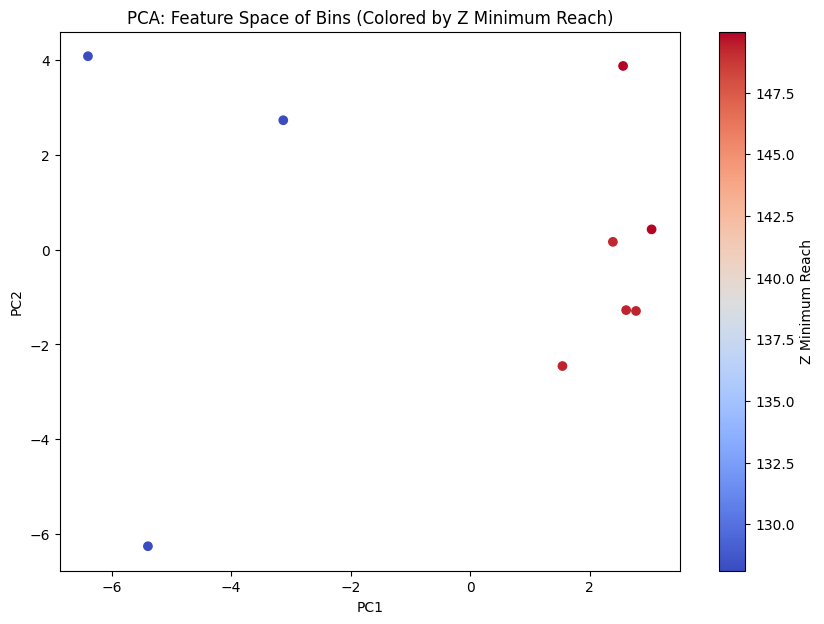

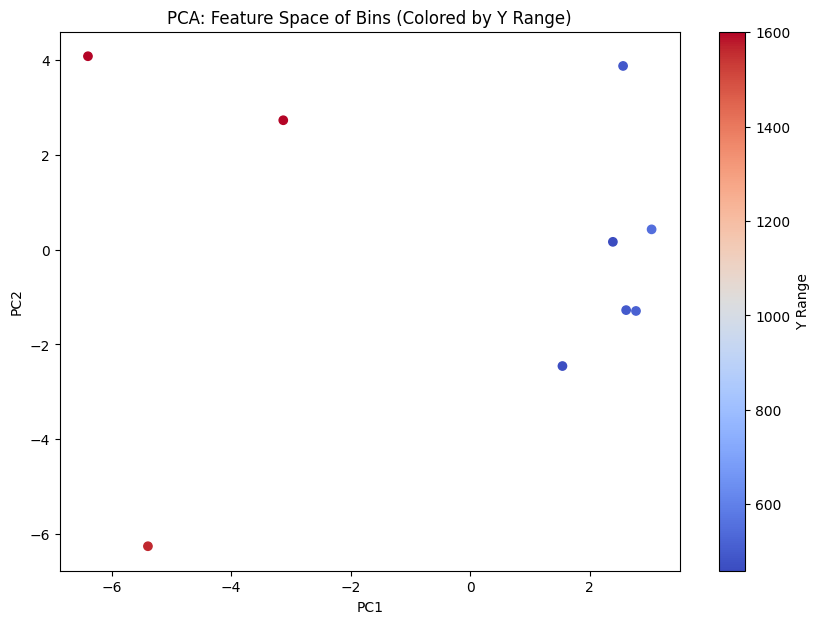

In [ ]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_features)

pca = PCA(n_components=2)
components = pca.fit_transform(features_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], c=df_features['z_min_reach'], cmap='coolwarm')
plt.title('PCA: Feature Space of Bins (Colored by Z Minimum Reach)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Z Minimum Reach')
plt.show()


plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], c=df_features['y_range'], cmap='coolwarm')
plt.title('PCA: Feature Space of Bins (Colored by Y Range)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Y Range')
plt.show()

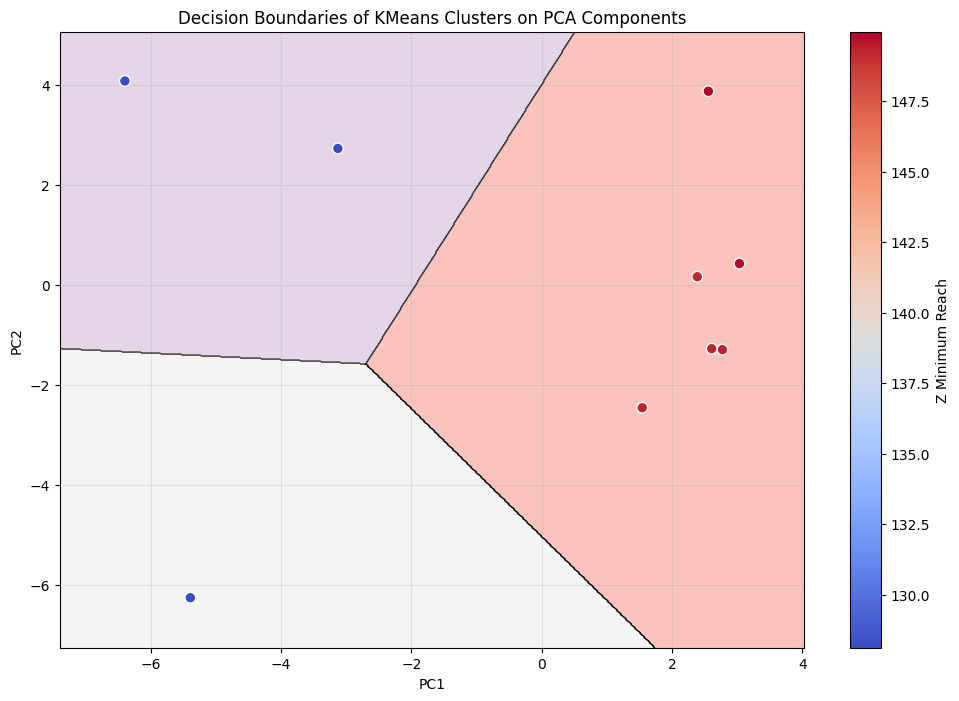

In [26]:


# KMeans on PCA components
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(components)

h = .02 
x_min, x_max = components[:, 0].min() - 1, components[:, 0].max() + 1
y_min, y_max = components[:, 1].min() - 1, components[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, cmap='Pastel1', alpha=0.8)
plt.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5)
scatter = plt.scatter(components[:, 0], components[:, 1], 
                      c=df_features['z_min_reach'], cmap='coolwarm', 
                      edgecolors='white', s=60, zorder=3)


plt.colorbar(scatter, label='Z Minimum Reach')
plt.title('Decision Boundaries of KMeans Clusters on PCA Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)

plt.show()

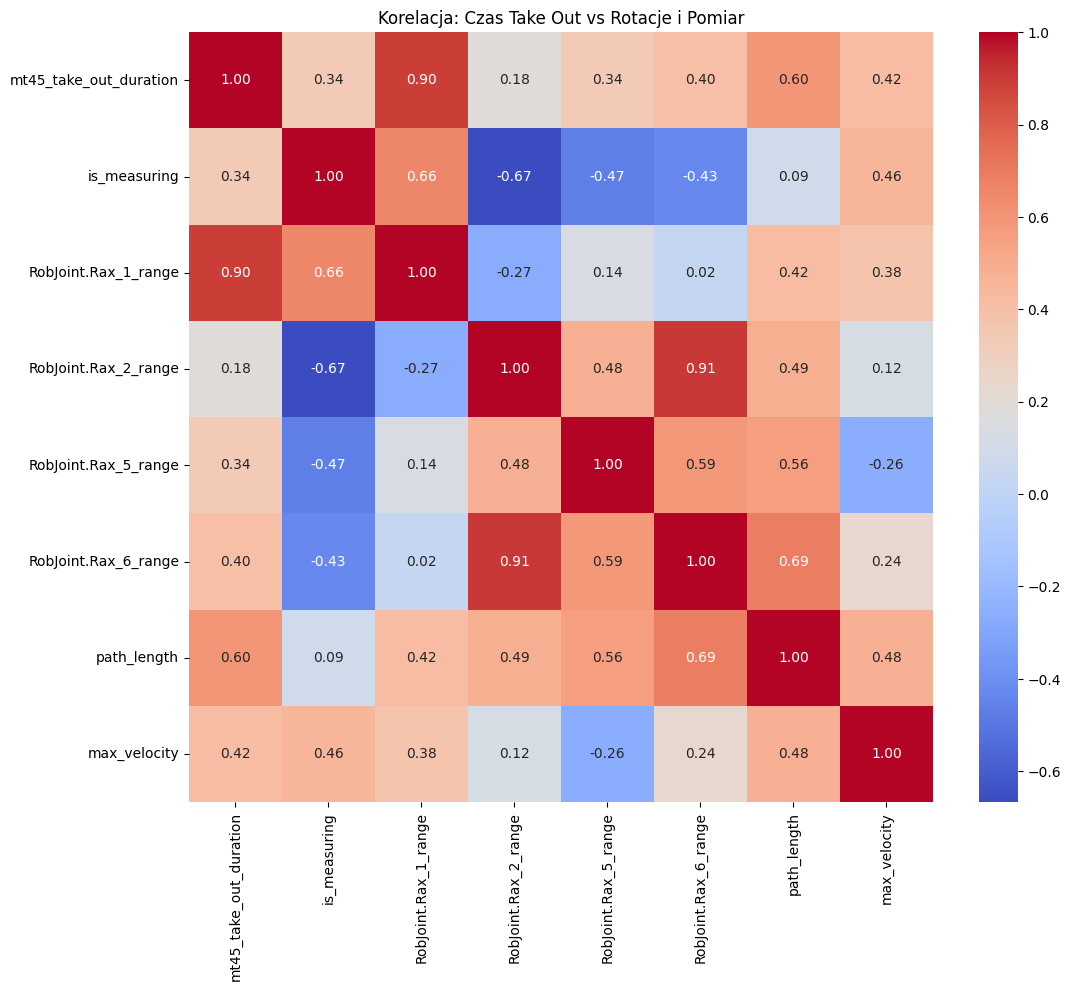

In [29]:
cols_to_check = [
    'mt45_take_out_duration', 'is_measuring', 
    'RobJoint.Rax_1_range', 'RobJoint.Rax_2_range', 
    'RobJoint.Rax_5_range', 'RobJoint.Rax_6_range',
    'path_length', 'max_velocity'
]

plt.figure(figsize=(12, 10))
correlation_matrix = df_features[cols_to_check].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelacja: Czas Take Out vs Rotacje i Pomiar')
plt.show()